# Breast Cancer Detection — MLflow Experiment Tracking

*Last updated: 2026-03-28*

This notebook walks through the full ML model lifecycle using MLflow: experiment tracking, hyperparameter tuning with LightGBM, model registry, and serving.

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
data = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data['target'] = cancer.target

In [2]:
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
data.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
# Class distribution: 0 = malignant, 1 = benign
data['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [5]:
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


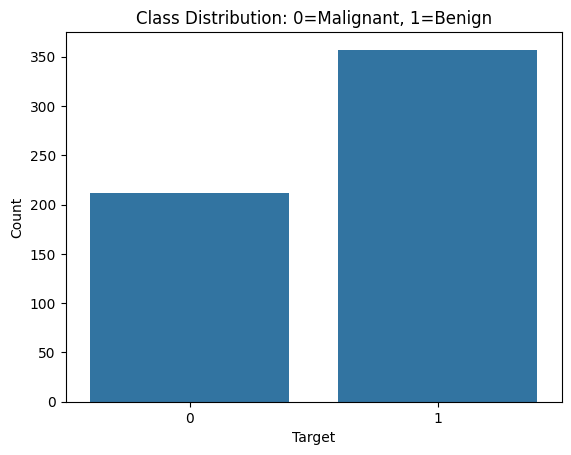

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=data)
plt.title('Class Distribution: 0=Malignant, 1=Benign')
plt.xlabel('Target')
plt.ylabel('Count');

The breast cancer dataset contains 569 samples: 212 malignant (class 0) and 357 benign (class 1).

The target is already binary, so no binarisation step is needed.

In [7]:
data.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

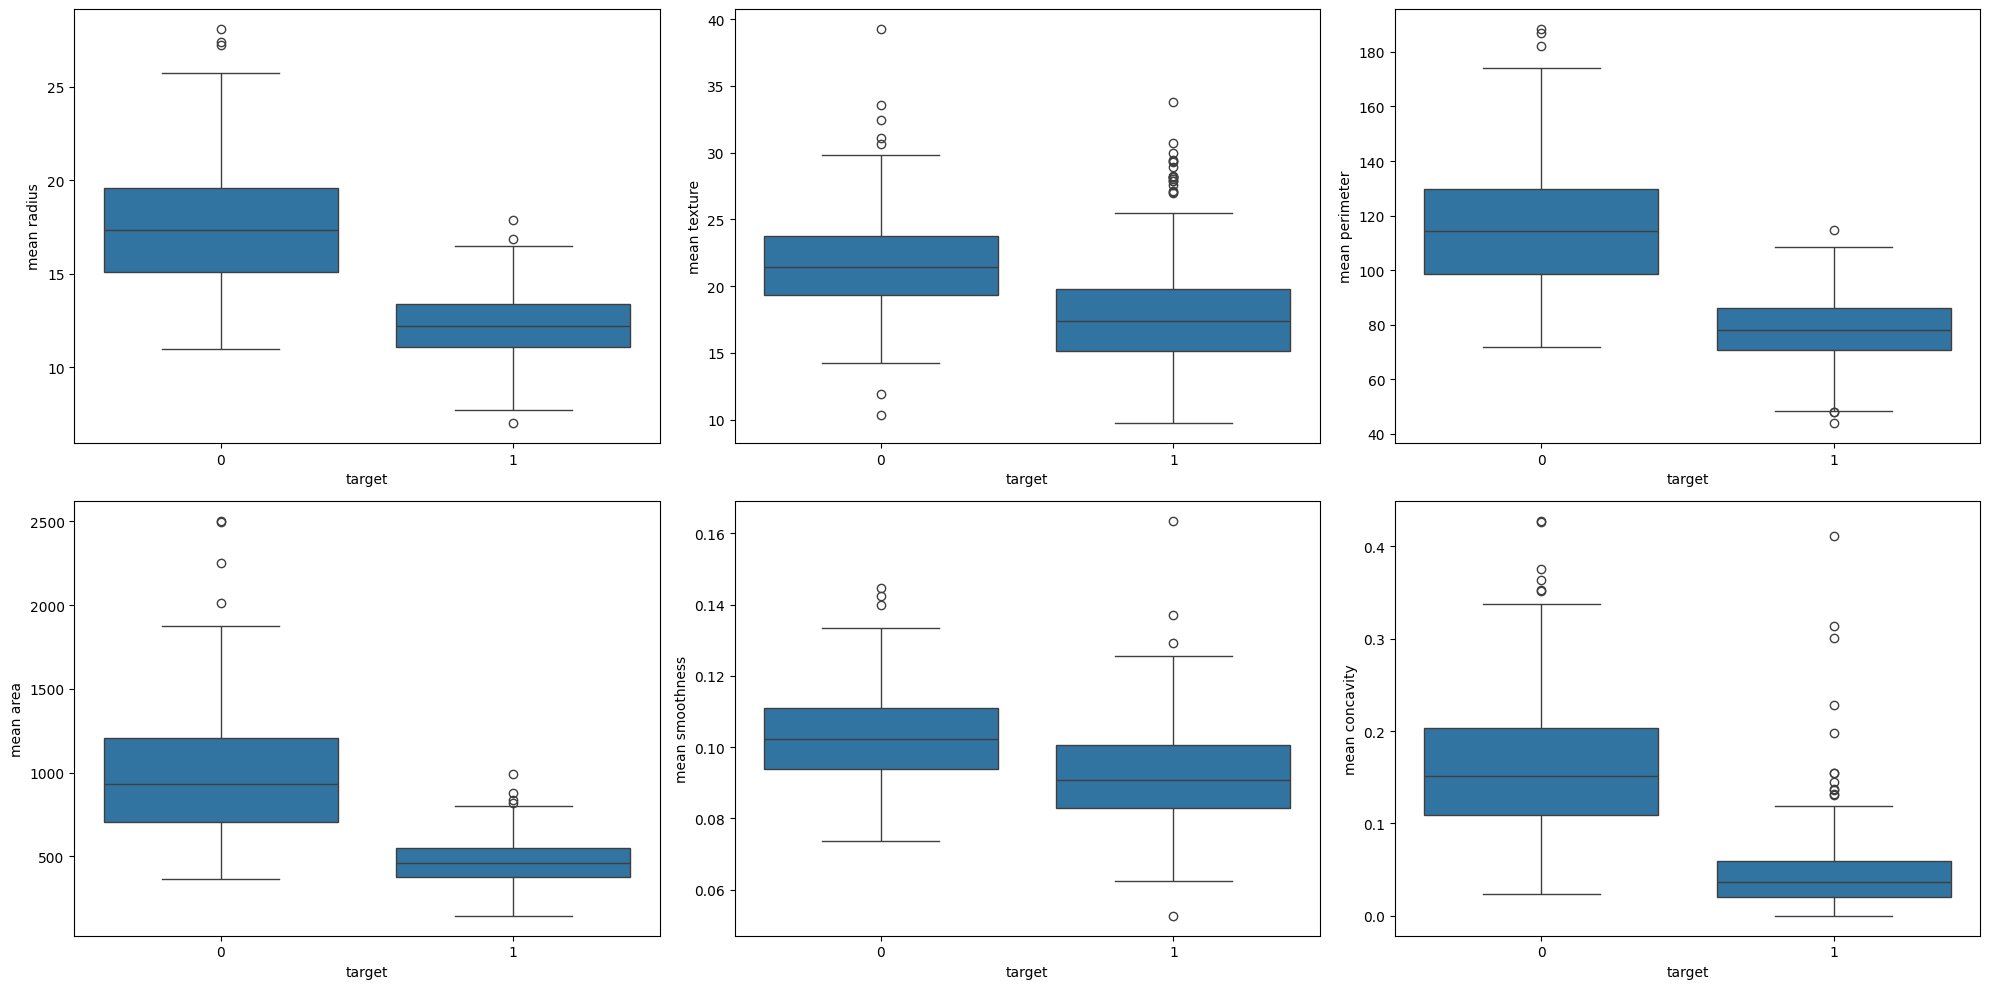

In [8]:
import matplotlib.pyplot as plt

# Show box plots for a representative subset of the 30 features
selected_features = ['mean radius', 'mean texture', 'mean perimeter',
                     'mean area', 'mean smoothness', 'mean concavity']

dims = (2, 3)
f, axes = plt.subplots(dims[0], dims[1], figsize=(20, 10))
axis_i, axis_j = 0, 0
for col in selected_features:
    sns.boxplot(x='target', y=col, data=data, ax=axes[axis_i, axis_j])
    axis_j += 1
    if axis_j == dims[1]:
        axis_i += 1
        axis_j = 0
plt.tight_layout();

In the above box plots, several features stand out as strong univariate predictors of malignancy.

Mean radius, mean perimeter, and mean area are noticeably larger in malignant samples (class 0), meaning tumour size is positively correlated with malignancy.

Mean concavity is also higher in malignant samples, reflecting more irregular tumour shapes.

In [9]:
data.isna().any()


mean radius                False
mean texture               False
mean perimeter             False
mean area                  False
mean smoothness            False
mean compactness           False
mean concavity             False
mean concave points        False
mean symmetry              False
mean fractal dimension     False
radius error               False
texture error              False
perimeter error            False
area error                 False
smoothness error           False
compactness error          False
concavity error            False
concave points error       False
symmetry error             False
fractal dimension error    False
worst radius               False
worst texture              False
worst perimeter            False
worst area                 False
worst smoothness           False
worst compactness          False
worst concavity            False
worst concave points       False
worst symmetry             False
worst fractal dimension    False
target    

In [10]:
from sklearn.model_selection import train_test_split

X = data.drop(["target"], axis=1)
y = data["target"]

# Split out the training data (60%), using stratify to preserve class balance
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=123, stratify=y)

# Split the remaining 40% equally into validation (20%) and test (20%)
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=123, stratify=y_rem)

### Build a baseline model

This task is well suited to a random forest classifier, since the target is binary and there are complex interactions between the 30 numeric tumour features.

The following code builds a simple classifier using scikit-learn. It uses MLflow to keep track of the model accuracy, and to save the model for later use.

In [11]:
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from mlflow.models.signature import infer_signature
from mlflow.utils.environment import _mlflow_conda_env
import cloudpickle
import time
 
# The predict method of sklearn's RandomForestClassifier returns a binary classification (0 or 1). 
# The following code creates a wrapper function, SklearnModelWrapper, that uses 
# the predict_proba method to return the probability that the observation belongs to each class. 
 
class SklearnModelWrapper(mlflow.pyfunc.PythonModel):
  def __init__(self, model):
    self.model = model
    
  def predict(self, context, model_input):
    return self.model.predict_proba(model_input)[:,1]


# mlflow.start_run creates a new MLflow run to track the performance of this model. 
# Within the context, you call mlflow.log_param to keep track of the parameters used, and
# mlflow.log_metric to record metrics like accuracy.
with mlflow.start_run(run_name='untuned_random_forest'):
    n_estimators = 10
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=np.random.RandomState(123))
    model.fit(X_train, y_train)

    # predict_proba returns [prob_negative, prob_positive], so slice the output with [:, 1]
    predictions_test = model.predict_proba(X_test)[:,1]
    auc_score = roc_auc_score(y_test, predictions_test)
    mlflow.log_param('n_estimators', n_estimators)
    # Use the area under the ROC curve as a metric.
    mlflow.log_metric('auc', auc_score)
    wrappedModel = SklearnModelWrapper(model)
    # Log the model with a signature that defines the schema of the model's inputs and outputs. 
    # When the model is deployed, this signature will be used to validate inputs.
    signature = infer_signature(X_train, wrappedModel.predict(None, X_train))
    
    # MLflow contains utilities to create a conda environment used to serve models.
    # The necessary dependencies are added to a conda.yaml file which is logged along with the model.
    conda_env =  _mlflow_conda_env(
            additional_conda_deps=None,
            additional_pip_deps=["cloudpickle=={}".format(cloudpickle.__version__), "scikit-learn=={}".format(sklearn.__version__)],
            additional_conda_channels=None,
        )
    mlflow.pyfunc.log_model("random_forest_model",
                            python_model=wrappedModel,
                            conda_env=conda_env,
                            signature=signature)

/Users/dragonfruit/1-Projects/Code/ie7374-labs-experiment_tracking_labs-mlflow_labs-lab2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/dragonfruit/1-Projects/Code/ie7374-labs-experiment_tracking_labs-mlflow_labs-lab2/.venv/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/03/02 13:41:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/02 13:41:25 WARNING mlflow.models.model: `artifact_path` 

In [12]:
feature_importances = pd.DataFrame(model.feature_importances_, index=X_train.columns.tolist(), columns=['importance'])
feature_importances.sort_values('importance', ascending=False)

,importance
worst area,0.227482
worst perimeter,0.147020
worst concave points,0.080856
mean concavity,0.073841
mean area,0.071489
mean concave points,0.062853
area error,0.056261
worst concavity,0.051267
worst texture,0.031182
mean texture,0.028550


As illustrated by the boxplots shown previously, mean radius, mean perimeter, and mean concavity are important predictors of malignancy.

You logged the Area Under the ROC Curve (AUC) to MLflow. Click Experiment at the upper right to display the Experiment Runs sidebar.

A random classifier would have an AUC of 0.5, and higher AUC values are better. For more information, see Receiver Operating Characteristic Curve.

Register the model in MLflow Model Registry
By registering this model in Model Registry, you can easily reference the model from anywhere.

In [13]:
run_id = mlflow.search_runs(filter_string='tags.mlflow.runName = "untuned_random_forest"').iloc[0].run_id

In [14]:
run_id

'8f633f7ca1a24836a5d84dd23b850e27'

In [15]:
# If you see the error "PERMISSION_DENIED: User does not have any permission level assigned to the registered model", 
# the cause may be that a model already exists with the name "cancer_detection". Try using a different name.
model_name = "cancer_detection"
model_version = mlflow.register_model(f"runs:/{run_id}/random_forest_model", model_name)

# Registering the model takes a few seconds, so add a small delay
time.sleep(15)

Registered model 'cancer_detection' already exists. Creating a new version of this model...
2026/03/02 13:41:25 WARNING mlflow.tracking._model_registry.fluent: Run with id 8f633f7ca1a24836a5d84dd23b850e27 has no artifacts at artifact path 'random_forest_model', registering model based on models:/m-0068ad84aeaf45b9b8417e8f77731600 instead
Created version '12' of model 'cancer_detection'.


In [16]:
"""
The MlflowClient class allows you to interact with the MLflow Tracking Server programmatically. 
You can use it to perform various tasks, such as creating and managing experiments, starting 
and managing runs, logging metrics and parameters, and querying information about experiments and runs.

"""
from mlflow.tracking import MlflowClient
client = MlflowClient()

client.transition_model_version_stage(
  name=model_name,
  version=model_version.version,
  stage="Production",
)

/var/folders/pc/fpkzlwx11y3fw3l831gdm3h40000gn/T/ipykernel_48108/2553610896.py:10: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1772476885546, current_stage='Production', deployment_job_state=None, description=None, last_updated_timestamp=1772476900600, metrics=None, model_id=None, name='cancer_detection', params=None, run_id='8f633f7ca1a24836a5d84dd23b850e27', run_link=None, source='models:/m-0068ad84aeaf45b9b8417e8f77731600', status='READY', status_message=None, tags={}, user_id=None, version=12, workspace='default'>

The Models page now shows the model version in stage "Production".

You can now refer to the model using the path "models:/cancer_detection/production".

In [17]:
model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")

# Sanity-check: This should match the AUC logged by MLflow
print(f'AUC: {roc_auc_score(y_test, model.predict(X_test))}')

AUC: 0.9831313462168358


In [18]:
# Run this in a separate terminal, not here — it starts a blocking server process.
# uv run mlflow ui --port 5001
# Then open http://localhost:5001

## Experiment with a new model

The random forest model performed well even without hyperparameter tuning.

The following code uses the LightGBM library to train a more accurate model. It runs a parallel hyperparameter sweep to train multiple models in parallel, using Hyperopt and SparkTrials. As before, the code tracks the performance of each parameter configuration with MLflow.

In [19]:
from hyperopt import fmin, tpe, hp, SparkTrials, Trials, STATUS_OK
from hyperopt.pyll import scope
import mlflow.lightgbm
import numpy as np
import lightgbm as lgb

# LightGBM grows leaf-wise (not depth-wise), so num_leaves is the primary complexity parameter
search_space = {
  'num_leaves': scope.int(hp.quniform('num_leaves', 20, 150, 1)),
  'learning_rate': hp.loguniform('learning_rate', -3, 0),
  'reg_alpha': hp.loguniform('reg_alpha', -5, -1),   # L1 regularisation
  'reg_lambda': hp.loguniform('reg_lambda', -6, -1),  # L2 regularisation
  'min_child_samples': scope.int(hp.quniform('min_child_samples', 5, 100, 1)),
  'objective': 'binary',
  'metric': 'auc',
  'seed': 123,
  'verbose': -1,
}

In [20]:
# Compatibility shim: hyperopt uses pkg_resources which was removed in Python 3.12+
# This patches in the two functions hyperopt.atpe actually calls, using the modern
# importlib.resources API as the backend.
import sys
try:
    import pkg_resources
except ImportError:
    import types
    import importlib
    import importlib.resources as _ir

    class _PkgResources(types.ModuleType):
        def resource_string(self, package_or_requirement, resource_name):
            return _ir.files(package_or_requirement).joinpath(resource_name).read_bytes()

        def resource_stream(self, package_or_requirement, resource_name):
            import io
            return io.BytesIO(self.resource_string(package_or_requirement, resource_name))

    _shim = _PkgResources('pkg_resources')
    sys.modules['pkg_resources'] = _shim


Nested Runs: When you use mlflow.start_run(nested=True) within the main run, you create nested runs. These runs are associated with the main run and inherit some of its parameters and context. Nested runs are typically used to explore variations or sub-experiments within the main experiment.

python
Copy code
import mlflow

with mlflow.start_run():
    # Your main experiment code goes here

    with mlflow.start_run(nested=True):
        # Nested experiment code goes here
Parameters and metrics logged in the nested run are associated with that specific run and can be accessed separately from the main run.
You can create multiple nested runs within a main run to represent different variations or configurations of your experiment.
python
Copy code
import mlflow

with mlflow.start_run():
    # Your main experiment code goes here

    with mlflow.start_run(nested=True):
        # Nested experiment code 1 goes here

    with mlflow.start_run(nested=True):
        # Nested experiment code 2 goes here

In [21]:
def train_model(params):
    # With MLflow autologging, hyperparameters and the trained model are automatically logged to MLflow.
    mlflow.lightgbm.autolog()
    with mlflow.start_run(nested=True):
        train = lgb.Dataset(data=X_train, label=y_train)
        validation = lgb.Dataset(data=X_val, label=y_val, reference=train)

        # early_stopping(50) stops training when validation AUC does not improve for 50 rounds.
        # log_evaluation(period=50) reduces console output to every 50 rounds.
        callbacks = [lgb.early_stopping(50), lgb.log_evaluation(period=50)]

        booster = lgb.train(
            params=params,
            train_set=train,
            num_boost_round=1000,
            valid_sets=[validation],
            valid_names=["validation"],
            callbacks=callbacks,
        )

        # LightGBM booster.predict() accepts a raw DataFrame or array directly (not a Dataset)
        validation_predictions = booster.predict(X_val)
        auc_score = roc_auc_score(y_val, validation_predictions)
        mlflow.log_metric('auc', auc_score)

        signature = infer_signature(X_train, booster.predict(X_train))
        mlflow.lightgbm.log_model(booster, "model", signature=signature)

        # Set the loss to -1*auc_score so fmin maximizes the auc_score
        return {'status': STATUS_OK, 'loss': -1*auc_score}


In [22]:
# !python3 -m pip install pyspark

In [23]:
# Importing pyspark, the Python API for Spark which lets you write Spark applications using Python
import pyspark  
# Importing specific Spark classes to manage configurations and the Spark context
from pyspark import SparkContext, SparkConf  

# Setting up the configuration for Spark:
conf_spark = SparkConf().set("spark.driver.host", "127.0.0.1")  # Configures the Spark driver host address to localhost

# Creating a SparkContext using the above configuration, essential for connecting to a Spark cluster:
sc = SparkContext(conf=conf_spark)  # Initializes the main entry point for Spark functionality


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/02 13:41:47 WARN Utils: Your hostname, dragonfruit-mbpro-396.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.152 instead (on interface en0)
26/03/02 13:41:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/02 13:41:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [24]:
import pyspark

TPE stands for Tree-structured Parzen Estimator. It's a Bayesian optimization technique that models the probability distribution of the hyperparameters given the observed metrics. It is particularly effective for high-dimensional spaces and has become a popular choice in machine learning for hyperparameter tuning.


In [37]:
# Greater parallelism will lead to speedups, but a less optimal hyperparameter sweep.
# A reasonable value for parallelism is the square root of max_evals.
spark_trials = SparkTrials(parallelism=10)

# Run fmin within an MLflow run context so that each hyperparameter configuration is logged as a child run of a parent
# run called "lgbm_models".
with mlflow.start_run(run_name='lgbm_models'):
  best_params = fmin(
    fn=train_model,
    space=search_space,
    algo=tpe.suggest,
    max_evals=96,
    trials=spark_trials,
  )


  0%|                                              | 0/96 [00:00<?, ?trial/s, best loss=?]

/Users/dragonfruit/1-Projects/Code/ie7374-labs-experiment_tracking_labs-mlflow_labs-lab2/.venv/lib/python3.11/site-packages/pyspark/util.py:457: UserWarning: Spark session is not provided. Tags will not be inherited.
  warnings.warn(

Training until validation scores don't improve for 50 rounds8:>   (0 + 1) / 1]1]
[50]	validation's auc: 0.992394
Early stopping, best iteration is:
[3]	validation's auc: 0.994544
2026/03/02 13:47:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training until validation scores don't improve for 50 rounds
[50]	validation's auc: 0.991733
[100]	validation's auc: 0.994709
Early stopping, best iteration is:
[99]	validation's auc: 0.994709
2026/03/02 13:47:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training until validation scores don't improve for 50 rounds
[50]	validation's auc: 0.992725
[100]	validation's auc: 0.994709
[150]	validation's auc: 0.996032
[200]	validation's a

  1%|▏                  | 1/96 [00:14<22:17, 14.08s/trial, best loss: -0.9945436507936508]

2026/03/02 13:47:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/02 13:47:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/02 13:47:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training until validation scores don't improve for 50 rounds9:>   (0 + 1) / 1]
[50]	validation's auc: 0.994709
[100]	validation's auc: 0.997024
Early stopping, best iteration is:
[97]	validation's auc: 0.997024
2026/03/02 13:47:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/02 13:47:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/02 13:47:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be add

  2%|▍                  | 2/96 [00:16<10:56,  6.98s/trial, best loss: -0.9947089947089947]

...

2026/03/02 13:50:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/02 13:50:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/02 13:50:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
[Stage 190:>                (0 + 1) / 1][Stage 191:>                (0 + 1) / 1]

 99%|█████████████████▊| 95/96 [02:45<00:01,  1.44s/trial, best loss: -0.9993386243386243]

2026/03/02 13:50:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/02 13:50:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                

100%|██████████████████| 96/96 [02:47<00:00,  1.75s/trial, best loss: -0.9993386243386243]


Total Trials: 96: 96 succeeded, 0 failed, 0 cancelled.


In [38]:
best_run = mlflow.search_runs(order_by=['metrics.auc DESC']).iloc[0]
print(f'AUC of Best Run: {best_run["metrics.auc"]}')

AUC of Best Run: 0.9993386243386243


## Update the production cancer_detection model in MLflow Model Registry

Earlier, you saved the baseline model to Model Registry with the name cancer_detection. Now that you have created a more accurate LightGBM model, update cancer_detection.

In [39]:
new_model_version = mlflow.register_model(f"runs:/{best_run.run_id}/model", model_name)
 
# Registering the model takes a few seconds, so add a small delay
time.sleep(10)

Registered model 'cancer_detection' already exists. Creating a new version of this model...
2026/03/02 13:50:08 WARNING mlflow.tracking._model_registry.fluent: Run with id 2fba6ce2711d40b29d3d68cb7a38a8ca has no artifacts at artifact path 'model', registering model based on models:/m-672ce0d1ddca4816a71c81c6bbdad676 instead
Created version '14' of model 'cancer_detection'.


Click Models in the left sidebar to see that the cancer_detection model now has two versions.

The following code promotes the new version to production.

In [40]:
client.transition_model_version_stage(
    name=model_name,
    version=model_version.version,
    stage='Archived'
)

client.transition_model_version_stage(
    name=model_name,
    version=new_model_version.version,
    stage='Production'
)

/var/folders/pc/fpkzlwx11y3fw3l831gdm3h40000gn/T/ipykernel_48108/517306411.py:1: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(
/var/folders/pc/fpkzlwx11y3fw3l831gdm3h40000gn/T/ipykernel_48108/517306411.py:7: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1772477408236, current_stage='Production', deployment_job_state=None, description=None, last_updated_timestamp=1772477418281, metrics=None, model_id=None, name='cancer_detection', params=None, run_id='2fba6ce2711d40b29d3d68cb7a38a8ca', run_link=None, source='models:/m-672ce0d1ddca4816a71c81c6bbdad676', status='READY', status_message=None, tags={}, user_id=None, version=14, workspace='default'>

Clients that call load_model now receive the new model.



In [41]:
model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")
print(f"AUC: {roc_auc_score(y_test, model.predict(X_test))}")

AUC: 0.9842777595807403


## Batch inference

There are many scenarios where you might want to evaluate a model on a corpus of new data. For example, you may have a fresh batch of data, or may need to compare the performance of two models on the same corpus of data.

The following code evaluates the model on data stored in a Delta table, using Spark to run the computation in parallel.

In [42]:
mlflow.pyfunc.spark_udf?


Signature:
mlflow.pyfunc.spark_udf(
    spark,
    model_uri,
    result_type=None,
    env_manager=None,
    params: dict[str, typing.Any] | None = None,
    extra_env: dict[str, str] | None = None,
    prebuilt_env_uri: str | None = None,
    model_config: str | pathlib.Path | dict[str, typing.Any] | None = None,
)
Docstring:
A Spark UDF that can be used to invoke the Python function formatted model.

Parameters passed to the UDF are forwarded to the model as a DataFrame where the column names
are ordinals (0, 1, ...). On some versions of Spark (3.0 and above), it is also possible to
wrap the input in a struct. In that case, the data will be passed as a DataFrame with column
names given by the struct definition (e.g. when invoked as my_udf(struct('x', 'y')), the model
will get the data as a pandas DataFrame with 2 columns 'x' and 'y').

If a model contains a signature with tensor spec inputs, you will need to pass a column of
array type as a corresponding UDF argument. The column val

In [43]:
import mlflow.pyfunc

from pyspark.sql import SparkSession

# Create or retrieve a Spark session
spark = SparkSession.builder \
    .appName("MLflow Integration") \
    .config("spark.some.config.option", "config-value") \
    .getOrCreate()

apply_model_udf = mlflow.pyfunc.spark_udf(spark, f"models:/{model_name}/production")

2026/03/02 13:50:18 WARNING mlflow.pyfunc: Calling `spark_udf()` with `env_manager="local"` does not recreate the same environment that was used during training, which may lead to errors or inaccurate predictions. We recommend specifying `env_manager="conda"`, which automatically recreates the environment that was used to train the model and performs inference in the recreated environment.
2026/03/02 13:50:18 INFO mlflow.models.flavor_backend_registry: Selected backend for flavor 'python_function'


In [44]:
# new_data = spark.read.format("csv").load(table_path) # table_path is path to the delta table

In [45]:
new_model_version

<ModelVersion: aliases=[], creation_timestamp=1772477408236, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1772477408236, metrics=None, model_id=None, name='cancer_detection', params=None, run_id='2fba6ce2711d40b29d3d68cb7a38a8ca', run_link=None, source='models:/m-672ce0d1ddca4816a71c81c6bbdad676', status='READY', status_message=None, tags={}, user_id=None, version=14, workspace='default'>

In [46]:
new_model_version.run_id

'2fba6ce2711d40b29d3d68cb7a38a8ca'

In [47]:
# Serve the model using the MLflow Model Serving

# Run the following in terminal outside jupyter and after activating the virtual environment
# mlflow models serve --env-manager=local -m models:/cancer_detection/production -h 0.0.0.0 -p 5001

- Here **model_name** is `cancer_detection`

In [48]:
import requests
import json

url = 'http://localhost:5001/invocations'

datads_dict = {"dataframe_split": X_test.to_dict(orient='split')}

response = requests.post(url, json=datads_dict)
predictions = response.json()

print(predictions)

{'predictions': [0.21934137865209646, 0.9980093245403898, 0.997859907972458, 0.0032963611229279224, 0.0024565747021929973, 0.001807355142300071, 0.8121304113618637, 0.09503758520911165, 0.9953399281575782, 0.9956520402185836, 0.9558859761009375, 0.0032963611229279224, 0.9953399281575782, 0.005762683463739895, 0.0024243018132145827, 0.004035265454303976, 0.997859907972458, 0.004478046635910061, 0.23395903141214433, 0.9916611124780137, 0.8132302127499603, 0.9980093245403898, 0.9961544519197867, 0.9980093245403898, 0.9959442118781272, 0.9980093245403898, 0.7484048893892312, 0.0024565747021929973, 0.9977732932284689, 0.9980093245403898, 0.9449535546710701, 0.011245177174024913, 0.9980093245403898, 0.997859907972458, 0.9979227688310821, 0.003294403217341896, 0.2563841304788367, 0.22371116545139982, 0.9980093245403898, 0.001807355142300071, 0.0031631456195989715, 0.997859907972458, 0.9929591246535323, 0.001807355142300071, 0.004478046635910061, 0.0032963611229279224, 0.9934310593923872, 0.00

In [49]:
# Run this in a separate terminal, not here — it starts a blocking server process.
# uv run mlflow ui --port 5001
# Then open http://localhost:5001